In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score

# SMOTE와 Pipeline (Data Leakage 방지용)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import EditedNearestNeighbours
from imblearn.pipeline import Pipeline as ImbPipeline

In [21]:
# 1. 데이터 로드
url = "https://raw.githubusercontent.com/kzming2007/UR3_Cobot_ML/refs/heads/main/dataset/ur3_cobotops.csv"
df = pd.read_csv(url)

## Random Forest - SMOTE UnderSampling

### Cell 1: 데이터 로드 및 Feature Engineering

In [22]:
df.columns = df.columns.str.strip()
df.rename(columns={'Temperature_T0': 'Temperature_J0'}, inplace=True)

# 2. 결측치 없는 클린 데이터 분리
df_clean = df.dropna().copy()

# 3. 파생 변수 생성 (Power = Current * Speed 등)
current_cols = [f'Current_J{i}' for i in range(6)]
speed_cols = [f'Speed_J{i}' for i in range(6)]
temp_cols = [f'Temperature_J{i}' for i in range(6)]
for i in range(6):
    df_clean[f'Power_J{i}'] = df_clean[f'Current_J{i}'] * df_clean[f'Speed_J{i}']

df_clean['Total_Power_Electric'] = (df_clean[current_cols]**2).sum(axis=1)

# 4. 입력 피처(X) 설정
input_cols = current_cols + speed_cols + temp_cols + ['Tool_current'] + [f'Power_J{i}' for i in range(6)] + ['Total_Power_Electric']
X = df_clean[input_cols]

print(f"데이터 크기: {df_clean.shape}")
print(f"피처 개수: {len(input_cols)}개")

데이터 크기: (7355, 31)
피처 개수: 26개


### Cell 2: 타겟 변수 라벨링

In [23]:
# 통합 이진 타겟(System_Failure) 생성
df_clean['Robot_ProtectiveStop'] = df_clean['Robot_ProtectiveStop'].astype(bool).astype(int)
df_clean['grip_lost'] = df_clean['grip_lost'].astype(bool).astype(int)

y = ((df_clean['Robot_ProtectiveStop'] == 1) | (df_clean['grip_lost'] == 1)).astype(int)

print("분류된 타겟(y)의 클래스별 데이터 개수:")
print(y.value_counts().sort_index())

분류된 타겟(y)의 클래스별 데이터 개수:
0    6837
1     518
Name: count, dtype: int64


### Cell 3: 데이터 분할 및 스케일링
(참고: 트리 기반 모델은 스케일링이 필요 없으나, 파이프라인 안에서 거리 기반인 SMOTE가 작동하기 때문에 일관성을 위해 StandardScaler를 유지합니다.)

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"학습 데이터 크기: {X_train_scaled.shape}")
print(f"테스트 데이터 크기: {X_test_scaled.shape}")

학습 데이터 크기: (5884, 26)
테스트 데이터 크기: (1471, 26)


### Cell 4: Random Forest 학습 및 하이퍼파라미터 튜닝

In [25]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Imblearn Pipeline 구축 (SMOTE -> ENN -> RandomForest)
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('enn', EditedNearestNeighbours(n_neighbors=3, kind_sel='all')),
    ('rf', RandomForestClassifier(random_state=42))
])

# 파라미터 그리드 
param_grid = {
    #'rf__n_estimators': [100, 200],              
    #'rf__max_depth': [10, 15, 20, None],         
    #'rf__min_samples_split': [2, 5, 10],         
    #'rf__min_samples_leaf': [1, 2, 4]            
    'rf__n_estimators': [100, 200],            # 숲의 크기 (트리가 많을수록 안정적, 과적합을 유발하지 않음)
    'rf__max_depth': [15, 20, 25],         # 트리의 최대 깊이 제한
    'rf__min_samples_split': [8, 10, 15],      # 노드를 쪼개기 위한 최소 샘플 수 (허들 높이기)
    'rf__min_samples_leaf': [2, 4, 6],     # 이파리(끝 노드)에 남아야 하는 최소 샘플 수 (잔가지 치기)
    'rf__max_features': ['sqrt']  # 분할 시 고려할 최대 변수 개수 (트리들의 다양성 확보)
}

print("--- [SMOTE+ENN] Random Forest 하이퍼파라미터 탐색 및 5-Fold 교차 검증 진행 중 ---")
grid_search = GridSearchCV(
    estimator=pipeline, 
    param_grid=param_grid, 
    cv=skf, 
    scoring='f1_macro', 
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print("\n[GridSearchCV 결과]")
print("[최적의 하이퍼파라미터 설정]")
for param, value in grid_search.best_params_.items():
    print(f"  • {param.replace('rf__', '')}: {value}")
print("")
print(f"최고 교차 검증 F1-Macro 점수: {grid_search.best_score_:.4f}")

--- [SMOTE+ENN] Random Forest 하이퍼파라미터 탐색 및 5-Fold 교차 검증 진행 중 ---
Fitting 5 folds for each of 54 candidates, totalling 270 fits

[GridSearchCV 결과]
[최적의 하이퍼파라미터 설정]
  • max_depth: 25
  • max_features: sqrt
  • min_samples_leaf: 2
  • min_samples_split: 8
  • n_estimators: 200

최고 교차 검증 F1-Macro 점수: 0.7549


### Cell 5: 상위 10개 모델 비교 데이터프레임 (ROC-AUC 포함)

In [26]:
cv_results_df = pd.DataFrame(grid_search.cv_results_)
top_models = cv_results_df.sort_values('rank_test_score').head(10)

comparison_data = []
print("--- [모델 비교] 상위 10개 Random Forest (SMOTE+ENN) 성능 종합 ---")

for index, row in top_models.iterrows():
    params = row['params']
    rank = int(row['rank_test_score'])
    cv_f1 = row['mean_test_score']
    
    # 해당 파라미터로 파이프라인 재학습
    model = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('enn', EditedNearestNeighbours(n_neighbors=3, kind_sel='all')),
        ('rf', RandomForestClassifier(
            n_estimators=params.get('rf__n_estimators', 100),
            max_depth=params.get('rf__max_depth', None),
            min_samples_split=params.get('rf__min_samples_split', 2),
            min_samples_leaf=params.get('rf__min_samples_leaf', 1),
            max_features=params.get('rf__max_features', 'sqrt'),
            random_state=42
        ))
    ])
    model.fit(X_train_scaled, y_train)
    
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    y_test_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    train_f1 = f1_score(y_train, y_train_pred, average='macro')
    test_f1 = f1_score(y_test, y_test_pred, average='macro')
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    test_roc_auc = roc_auc_score(y_test, y_test_prob)
    
    e_val = params.get('rf__n_estimators', '-')
    d_val = params.get('rf__max_depth', 'None')
    s_val = params.get('rf__min_samples_split', '-')
    l_val = params.get('rf__min_samples_leaf', '-')
    f_val = params.get('rf__max_features', 'sqrt')
    param_short = f"E={e_val}, D={d_val}, S={s_val}, L={l_val}, F={f_val}"
    
    comparison_data.append({
        '순위': rank,
        'CV F1': round(cv_f1, 4),
        'Train F1': round(train_f1, 4),
        'Test F1': round(test_f1, 4),
        '과적합 Gap': round(train_f1 - test_f1, 4), 
        'Train Acc': round(train_acc, 6),
        'Test Acc': round(test_acc, 6),
        'Test ROC-AUC': round(test_roc_auc, 6),
        '파라미터 설정': param_short
    })

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

--- [모델 비교] 상위 10개 Random Forest (SMOTE+ENN) 성능 종합 ---


,순위,CV F1,Train F1,Test F1,과적합 Gap,Train Acc,Test Acc,Test ROC-AUC,파라미터 설정
0,1,0.7549,0.9696,0.7999,0.1697,0.991842,0.947655,0.936441,"E=200, D=25, S=8, L=2, F=sqrt"
1,2,0.7541,0.9684,0.7931,0.1753,0.991502,0.945615,0.937004,"E=100, D=25, S=8, L=2, F=sqrt"
2,3,0.7504,0.9526,0.8018,0.1508,0.986914,0.946295,0.941267,"E=100, D=25, S=8, L=4, F=sqrt"
3,4,0.7497,0.9654,0.8000,0.1654,0.990653,0.946975,0.938010,"E=200, D=25, S=10, L=2, F=sqrt"
4,5,0.7497,0.9401,0.7937,0.1465,0.983175,0.942896,0.938917,"E=200, D=20, S=10, L=4, F=sqrt"
5,6,0.7495,0.9383,0.7903,0.1479,0.982665,0.942216,0.939670,"E=200, D=25, S=10, L=6, F=sqrt"
6,6,0.7495,0.9383,0.7903,0.1479,0.982665,0.942216,0.939670,"E=200, D=25, S=8, L=6, F=sqrt"
7,8,0.7490,0.9583,0.7865,0.1718,0.988613,0.942896,0.937271,"E=200, D=25, S=8, L=4, F=sqrt"
8,9,0.7480,0.9368,0.7889,0.1478,0.982155,0.940857,0.936828,"E=100, D=25, S=8, L=6, F=sqrt"
9,9,0.7480,0.9368,0.7889,0.1478,0.982155,0.940857,0.936828,"E=100, D=25, S=10, L=6, F=sqrt"


### Cell 6: 특정 순위 모델 최종 평가지표 상세 분석

In [32]:
print("\n" + "="*50)
target_rank = 3
print(f"--- [상세 분석] {target_rank}위 모델 최종 평가지표 ---")
print("="*50)

selected_row = top_models[top_models['rank_test_score'] == target_rank].iloc[0]
selected_params = selected_row['params']

print(f"\n[선택된 {target_rank}위 모델의 하이퍼파라미터]")
for param, value in selected_params.items():
    print(f"  • {param.replace('rf__', '')}: {value}")

selected_model = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('enn', EditedNearestNeighbours(n_neighbors=3, kind_sel='all')),
    ('rf', RandomForestClassifier(
        n_estimators=selected_params.get('rf__n_estimators', 100),
        max_depth=selected_params.get('rf__max_depth', None),
        min_samples_split=selected_params.get('rf__min_samples_split', 2),
        min_samples_leaf=selected_params.get('rf__min_samples_leaf', 1),
        max_features=selected_params.get('rf__max_features', 'sqrt'),
        random_state=42
    ))
])
selected_model.fit(X_train_scaled, y_train)

y_train_pred_selected = selected_model.predict(X_train_scaled)
y_train_prob_selected = selected_model.predict_proba(X_train_scaled)[:, 1]
y_test_pred_selected = selected_model.predict(X_test_scaled)
y_test_prob_selected = selected_model.predict_proba(X_test_scaled)[:, 1]

def print_metrics(y_true, y_pred, y_prob, dataset_name):
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    roc_auc = roc_auc_score(y_true, y_prob)
    
    print(f"\n[{dataset_name} 데이터 평가]")
    print(f"Accuracy (정확도) : {acc:.4f}")
    print(f"F1-Macro Score    : {f1_macro:.6f}")
    print(f"ROC-AUC Score     : {roc_auc:.6f}")
    print(f"\n[{dataset_name} 상세 분류 리포트]")
    print(classification_report(y_true, y_pred, target_names=['0 (Normal)', '1 (Failure)']))

print_metrics(y_train, y_train_pred_selected, y_train_prob_selected, "Train")
print_metrics(y_test, y_test_pred_selected, y_test_prob_selected, "Test")

y_test_pred = y_test_pred_selected


--- [상세 분석] 3위 모델 최종 평가지표 ---

[선택된 3위 모델의 하이퍼파라미터]
  • max_depth: 25
  • max_features: sqrt
  • min_samples_leaf: 4
  • min_samples_split: 8
  • n_estimators: 100

[Train 데이터 평가]
Accuracy (정확도) : 0.9869
F1-Macro Score    : 0.952565
ROC-AUC Score     : 0.998147

[Train 상세 분류 리포트]
              precision    recall  f1-score   support

  0 (Normal)       1.00      0.99      0.99      5470
 1 (Failure)       0.86      0.97      0.91       414

    accuracy                           0.99      5884
   macro avg       0.93      0.98      0.95      5884
weighted avg       0.99      0.99      0.99      5884


[Test 데이터 평가]
Accuracy (정확도) : 0.9463
F1-Macro Score    : 0.801794
ROC-AUC Score     : 0.941267

[Test 상세 분류 리포트]
              precision    recall  f1-score   support

  0 (Normal)       0.97      0.97      0.97      1367
 1 (Failure)       0.61      0.65      0.63       104

    accuracy                           0.95      1471
   macro avg       0.79      0.81      0.80      1471
weig

### Cell 7: 오차 행렬(Confusion Matrix) 및 피처 중요도(Feature Importance) 시각화

--- [SMOTE+ENN + Random Forest] 3위 모델 오차 행렬 및 피처 중요도 ---


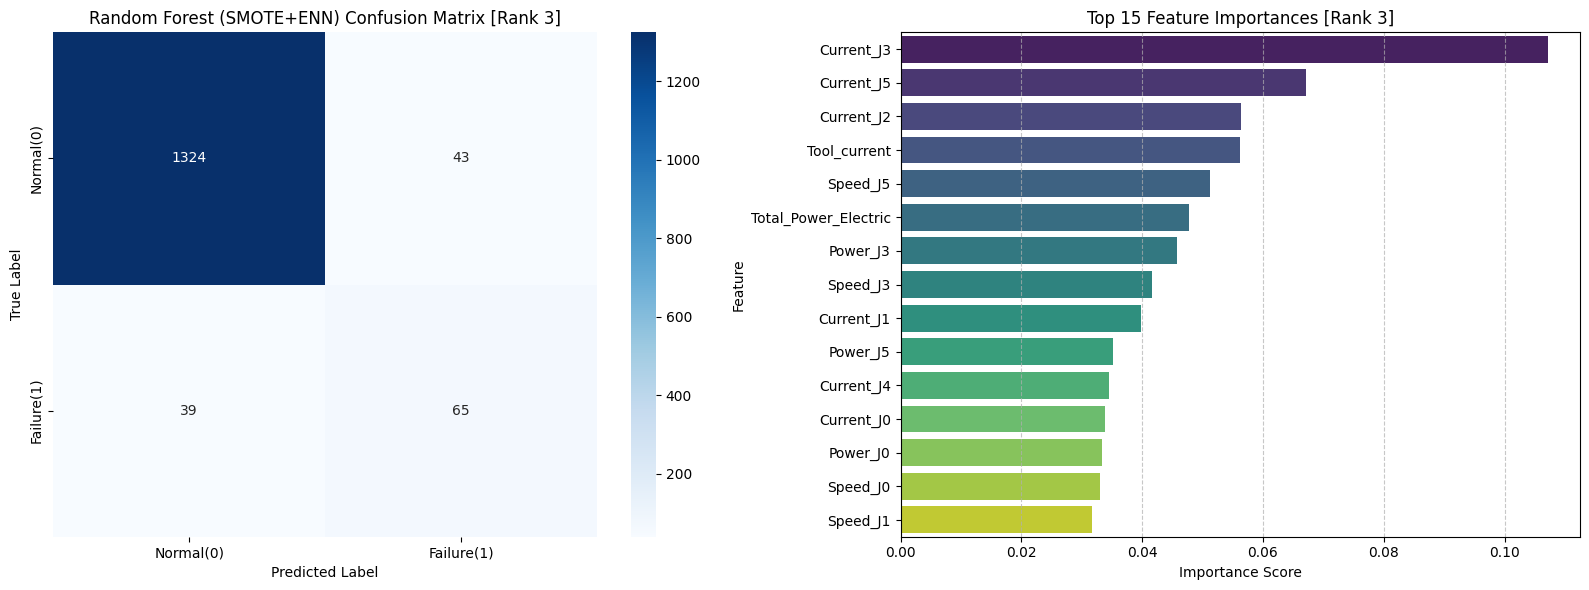

In [36]:
# ==========================================
# 시각화하고 싶은 모델의 순위를 지정하세요!
target_rank_cm = 3  
# ==========================================

print(f"--- [SMOTE+ENN + Random Forest] {target_rank_cm}위 모델 오차 행렬 및 피처 중요도 ---")

# 1. 지정한 순위의 하이퍼파라미터 추출
plot_row_cm = top_models[top_models['rank_test_score'] == target_rank_cm].iloc[0]
plot_params_cm = plot_row_cm['params']

# 2. 해당 파라미터로 파이프라인 생성 및 학습 (ENN 포함)
model_cm_enn = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('enn', EditedNearestNeighbours(n_neighbors=3, kind_sel='all')),
    ('rf', RandomForestClassifier(
        n_estimators=plot_params_cm.get('rf__n_estimators', 100),
        max_depth=plot_params_cm.get('rf__max_depth', None),
        min_samples_split=plot_params_cm.get('rf__min_samples_split', 2),
        min_samples_leaf=plot_params_cm.get('rf__min_samples_leaf', 1),
        max_features=plot_params_cm.get('rf__max_features', 'sqrt'),
        random_state=42, class_weight='balanced'
    ))
])
model_cm_enn.fit(X_train_scaled, y_train)
y_test_pred_cm_enn = model_cm_enn.predict(X_test_scaled)

# 3. 시각화 그리기
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# [왼쪽] Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred_cm_enn)
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', ax=axes[0], 
            xticklabels=['Normal(0)', 'Failure(1)'], yticklabels=['Normal(0)', 'Failure(1)'])
axes[0].set_title(f'Random Forest (SMOTE+ENN) Confusion Matrix [Rank {target_rank_cm}]')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# [오른쪽] Feature Importance
rf_step_enn = model_cm_enn.named_steps['rf']
importances = pd.DataFrame({
    'Feature': input_cols,
    'Importance': rf_step_enn.feature_importances_
})
importances = importances.sort_values(by='Importance', ascending=False).head(15)

sns.barplot(x='Importance', y='Feature', data=importances, palette='viridis', ax=axes[1])
axes[1].set_title(f'Top 15 Feature Importances [Rank {target_rank_cm}]')
axes[1].set_xlabel('Importance Score')
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Cell 8: PCA 2D 결정 경계 시각화

--- [SMOTE+ENN + Random Forest] 3위 모델 2D 결정 경계 시각화 ---
[적용된 3위 모델 파라미터]
  • max_depth: 25
  • max_features: sqrt
  • min_samples_leaf: 4
  • min_samples_split: 8
  • n_estimators: 100


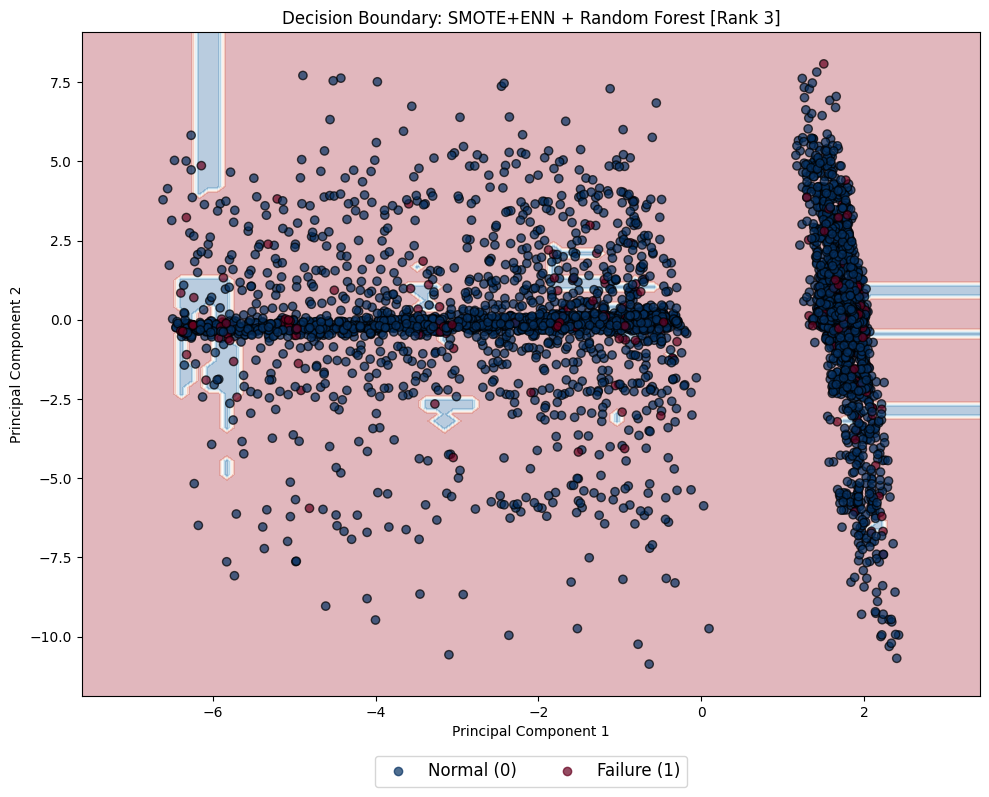

In [31]:
from sklearn.decomposition import PCA
from sklearn.inspection import DecisionBoundaryDisplay

target_rank_plot = 3

print(f"--- [SMOTE+ENN + Random Forest] {target_rank_plot}위 모델 2D 결정 경계 시각화 ---")

plot_row = top_models[top_models['rank_test_score'] == target_rank_plot].iloc[0]
plot_params = plot_row['params']

print(f"[적용된 {target_rank_plot}위 모델 파라미터]")
for param, value in plot_params.items():
    print(f"  • {param.replace('rf__', '')}: {value}")

pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)

model_smote_enn_pca = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('enn', EditedNearestNeighbours(n_neighbors=3, kind_sel='all')),
    ('rf', RandomForestClassifier(
        n_estimators=plot_params.get('rf__n_estimators', 100),
        max_depth=plot_params.get('rf__max_depth', None),
        min_samples_split=plot_params.get('rf__min_samples_split', 2),
        min_samples_leaf=plot_params.get('rf__min_samples_leaf', 1),
        max_features=plot_params.get('rf__max_features', 'sqrt'),
        random_state=42
    ))
])
model_smote_enn_pca.fit(X_train_pca, y_train)

fig, ax = plt.subplots(figsize=(10, 8))

DecisionBoundaryDisplay.from_estimator(
    model_smote_enn_pca, X_train_pca, response_method="predict",
    cmap=plt.cm.RdBu, alpha=0.3, ax=ax
)

scatter_kwargs = {'edgecolors': 'k', 'alpha': 0.7}
scatter = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap=plt.cm.RdBu_r, **scatter_kwargs)

ax.set_title(f"Decision Boundary: SMOTE+ENN + Random Forest [Rank {target_rank_plot}]")
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')

handles, labels = scatter.legend_elements()
ax.legend(handles, ['Normal (0)', 'Failure (1)'], loc='lower center', ncol=2, fontsize=12, bbox_to_anchor=(0.5, -0.15))

plt.tight_layout()
plt.show()

### Cell 9: ROC Curve, PR Curve로 시각화

--- [SMOTE+ENN + Random Forest] 3위 모델 ROC / PR Curve ---


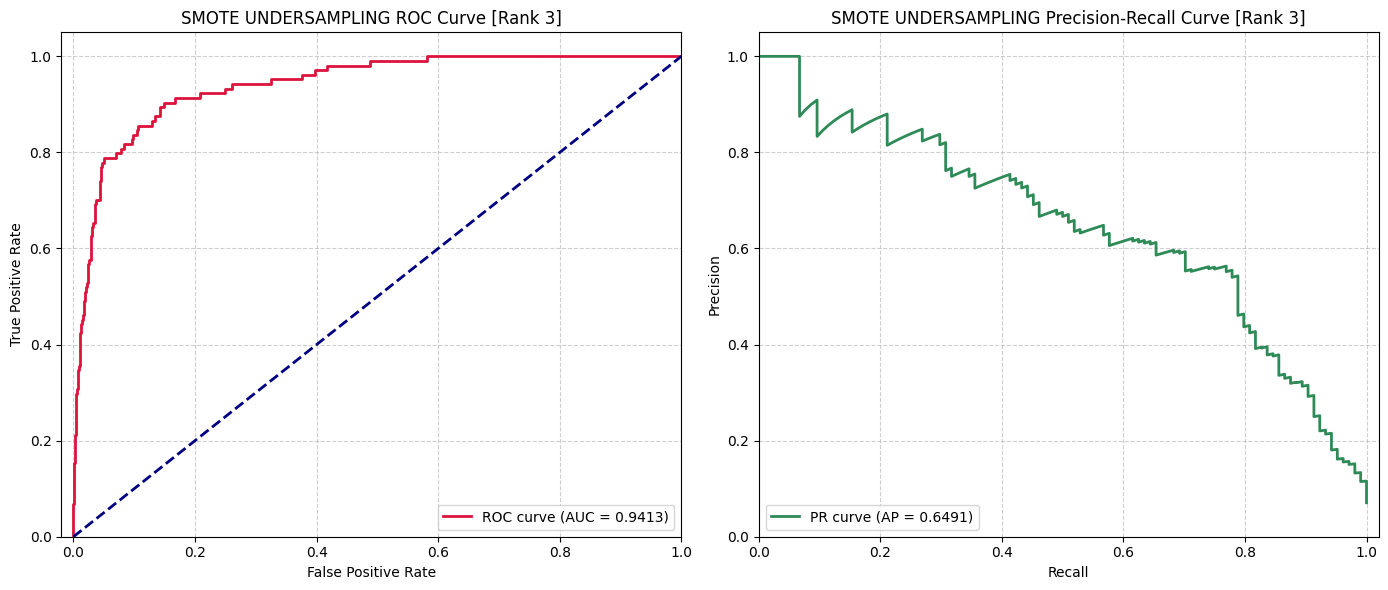

In [41]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# ==========================================
# 시각화하고 싶은 모델의 순위를 지정하세요!
target_rank_curve = 3  
# ==========================================

print(f"--- [SMOTE+ENN + Random Forest] {target_rank_curve}위 모델 ROC / PR Curve ---")

# 1. 파라미터 추출 및 파이프라인 학습
plot_row_curve = top_models[top_models['rank_test_score'] == target_rank_curve].iloc[0]
plot_params_curve = plot_row_curve['params']

model_curve_enn = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('enn', EditedNearestNeighbours(n_neighbors=3, kind_sel='all')),
    ('rf', RandomForestClassifier(
        n_estimators=plot_params_curve.get('rf__n_estimators', 100),
        max_depth=plot_params_curve.get('rf__max_depth', None),
        min_samples_split=plot_params_curve.get('rf__min_samples_split', 2),
        min_samples_leaf=plot_params_curve.get('rf__min_samples_leaf', 1),
        max_features=plot_params_curve.get('rf__max_features', 'sqrt'),
        random_state=42
    ))
])
model_curve_enn.fit(X_train_scaled, y_train)

# 확률 계산
y_test_prob_curve_enn = model_curve_enn.predict_proba(X_test_scaled)[:, 1]

# 2. 곡선 데이터 계산
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_prob_curve_enn)
roc_auc_val = auc(fpr, tpr)

# PR Curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_test_prob_curve_enn)
pr_auc_val = average_precision_score(y_test, y_test_prob_curve_enn)

# 3. 시각화 그리기
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# [왼쪽] ROC Curve
axes[0].plot(fpr, tpr, color='crimson', lw=2, label=f'ROC curve (AUC = {roc_auc_val:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlim([-0.02, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title(f'SMOTE UNDERSAMPLING ROC Curve [Rank {target_rank_curve}]')
axes[0].legend(loc="lower right")
axes[0].grid(True, linestyle='--', alpha=0.6)

# [오른쪽] PR Curve
axes[1].plot(recall_vals, precision_vals, color='seagreen', lw=2, label=f'PR curve (AP = {pr_auc_val:.4f})')
axes[1].set_xlim([0.0, 1.02])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title(f'SMOTE UNDERSAMPLING Precision-Recall Curve [Rank {target_rank_curve}]')
axes[1].legend(loc="lower left")
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()